# Your first TensorFlow SimpleRNN

**Learning objective:** Build, train and inspect a minimal Keras recurrent forecasting model.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:13:19.441287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974799.456100    2830 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974799.460513    2830 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:13:21.133482: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
t = np.arange(900); s = np.sin(t/18) + 0.2*np.sin(t/5)
lookback=24; X=[]; y=[]
for i in range(len(s)-lookback): X.append(s[i:i+lookback]); y.append(s[i+lookback])
X=np.asarray(X,dtype="float32")[...,None]; y=np.asarray(y,dtype="float32")
cut=700
model=tf.keras.Sequential([tf.keras.layers.Input((lookback,1)), tf.keras.layers.SimpleRNN(12), tf.keras.layers.Dense(1)])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()
hist=model.fit(X[:cut],y[:cut],validation_data=(X[cut:],y[cut:]),epochs=3,batch_size=32,verbose=0)
display(pd.DataFrame(hist.history).round(4))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 12)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

,loss,mae,val_loss,val_mae
0,0.0627,0.1860,0.0206,0.1153
1,0.0118,0.0895,0.0086,0.0762
2,0.0073,0.0694,0.0062,0.0652


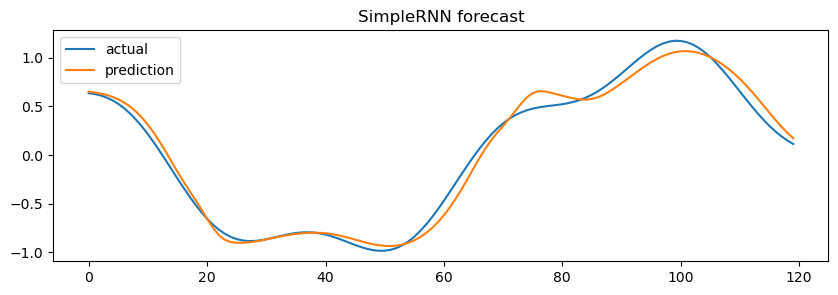

In [3]:
pred=model.predict(X[cut:cut+120],verbose=0).ravel()
plt.figure(figsize=(10,3)); plt.plot(y[cut:cut+120],label="actual"); plt.plot(pred,label="prediction"); plt.legend(); plt.title("SimpleRNN forecast"); plt.show()


A recurrent layer converts the entire history window into a learned representation. The Dense layer maps that representation to the numeric forecast.
